# 05_09 How low can article-store-day WAPE go?

The working target is **pooled WAPE ≤ 30% with near-zero bias at the
article-store-day (row) grain**, where the two-stage model currently stands at
**58.3% / −0.50%** after the `05_06`–`05_08` feature batches. Before spending
further iterations on that number, this notebook measures what is *attainable*
at that grain — for **any** forecasting method — using oracle forecasts that are
granted future knowledge, and maps the WAPE↔bias trade-off that constrains the
near-zero-bias requirement.

No model is trained here; every calculation uses the persisted two-stage
forecasts and actuals of the 20 evaluation origins.

## Method

**Oracle forecasts.** Each oracle is allowed to peek at the evaluation-period
actuals in a way no real forecast can, and is constructed to be unbiased. If an
oracle with future knowledge cannot reach 30% WAPE, no leakage-free model can:

1. *True series-weekday mean*: for every row, the series' true average demand on
   that weekday across all 20 evaluation weeks (includes the target day itself).
2. *Perfect occurrence + true positive means*: knows exactly **which** rows have
   positive demand (an upper bound no classifier can reach) and forecasts the
   series' — or series-weekday's — true average positive quantity on them.
3. *True weekly total × true weekday profile*: knows every series-week's exact
   total (perfect weekly forecasting) and allocates it over days using the
   series' true weekday profile.
4. *Hybrid decompositions*: perfect occurrence with the model's own quantity
   forecast, isolating how much of the current WAPE the occurrence stage is
   responsible for.

**Trade-off frontier.** Two decision rules applied to the existing forecasts —
global scaling (`c·forecast`) and zeroing rows below an occurrence-probability
threshold — trace how much WAPE can be bought by accepting negative bias. The
threshold rule approximates the L1-optimal forecast (the conditional median is
zero whenever P(demand > 0) < 0.5), so its endpoint approximates the WAPE-optimal
forecast the near-zero-bias requirement forbids.

In [2]:
from pathlib import Path
import sys

import duckdb
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.lightgbm import TWO_STAGE_MODEL_NAME
from src.models.results import result_path

pd.set_option('display.max_columns', 40)

design = load_benchmark_design()
forecast_path = result_path(TWO_STAGE_MODEL_NAME, design)
con = duckdb.connect()
con.execute('PRAGMA threads=4')
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE rows AS
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
           sourcing_group, category_id::INTEGER AS category_id,
           CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
           actual::DOUBLE AS actual, forecast::DOUBLE AS forecast,
           occurrence_probability::DOUBLE AS p_occ,
           positive_quantity_forecast::DOUBLE AS q_fc,
           EXTRACT(ISODOW FROM CAST(period AS DATE)) AS weekday
    FROM read_csv_auto(?)
    WHERE is_active
    ''',
    [str(forecast_path)],
)
overview = con.execute('''
    SELECT COUNT(*) AS active_rows,
           COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
           AVG((actual > 0)::INTEGER) AS occurrence_rate,
           AVG(actual) AS mean_demand_per_row,
           AVG(actual) FILTER (WHERE actual > 0) AS mean_positive_demand
    FROM rows
''').fetchdf()
display(overview.style.format({
    'active_rows': '{:,.0f}', 'series': '{:,.0f}', 'occurrence_rate': '{:.1%}',
    'mean_demand_per_row': '{:.3f}', 'mean_positive_demand': '{:.3f}',
}))

,active_rows,series,occurrence_rate,mean_demand_per_row,mean_positive_demand
0,"2,502,829","21,904",37.9%,1.063,2.805


## Oracle results

Every oracle is granted information that is impossible to have at forecast time
and is unbiased by construction.

In [3]:
def evaluate(name, forecast_sql):
    wape, bias = con.execute(f'''
        SELECT SUM(ABS(fo - actual)) / SUM(actual),
               SUM(fo - actual) / SUM(actual)
        FROM ({forecast_sql})
    ''').fetchone()
    return {'forecast': name, 'wape': wape, 'bias': bias}

results = [
    evaluate('two-stage model (leakage-free)',
             'SELECT actual, forecast AS fo FROM rows'),
    evaluate('ORACLE: true series-weekday mean', '''
        SELECT actual,
               AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday) AS fo
        FROM rows'''),
    evaluate('ORACLE: perfect occurrence + true series positive mean', '''
        WITH s AS (SELECT ARTIKEL_ID, MARKT_ID,
                          AVG(actual) FILTER (WHERE actual > 0) AS mu
                   FROM rows GROUP BY 1, 2)
        SELECT rows.actual,
               CASE WHEN rows.actual > 0 THEN COALESCE(s.mu, 0) ELSE 0 END AS fo
        FROM rows JOIN s USING (ARTIKEL_ID, MARKT_ID)'''),
    evaluate('ORACLE: perfect occurrence + true series-weekday positive mean', '''
        WITH s AS (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                          AVG(actual) FILTER (WHERE actual > 0) AS mu
                   FROM rows GROUP BY 1, 2, 3)
        SELECT rows.actual,
               CASE WHEN rows.actual > 0 THEN COALESCE(s.mu, 0) ELSE 0 END AS fo
        FROM rows JOIN s USING (ARTIKEL_ID, MARKT_ID, weekday)'''),
    evaluate('ORACLE: true weekly total x true weekday profile', '''
        WITH wd AS (SELECT ARTIKEL_ID, MARKT_ID, weekday, AVG(actual) AS mu
                    FROM rows GROUP BY 1, 2, 3),
        j AS (SELECT rows.*, wd.mu
              FROM rows JOIN wd USING (ARTIKEL_ID, MARKT_ID, weekday)),
        wk AS (SELECT *,
                      SUM(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, origin)
                          AS week_total,
                      SUM(mu) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, origin)
                          AS mu_sum
               FROM j)
        SELECT actual,
               CASE WHEN mu_sum > 0 THEN week_total * mu / mu_sum ELSE 0 END AS fo
        FROM wk'''),
    evaluate('HYBRID: perfect occurrence x model quantity forecast', '''
        SELECT actual,
               CASE WHEN actual > 0 THEN q_fc ELSE 0 END AS fo
        FROM rows'''),
]
oracle_table = pd.DataFrame(results)
display(oracle_table.style.format({'wape': '{:.2%}', 'bias': '{:+.2%}'}))

,forecast,wape,bias
0,two-stage model (leakage-free),58.18%,-0.89%
1,ORACLE: true series-weekday mean,92.85%,+0.00%
2,ORACLE: perfect occurrence + true series positive mean,71.26%,-0.00%
3,ORACLE: perfect occurrence + true series-weekday positive mean,63.85%,+0.00%
4,ORACLE: true weekly total x true weekday profile,43.73%,+0.00%
5,HYBRID: perfect occurrence x model quantity forecast,45.92%,-1.19%


## The WAPE↔bias frontier

The near-zero-bias requirement is binding: for zero-inflated demand the
L1-optimal (WAPE-minimizing) forecast is the conditional **median**, which is
zero on every row whose occurrence probability is below one half — a forecast
that would be biased low by design. The two rules below trace how much WAPE can
be bought by relaxing the bias requirement, using the existing model outputs.

In [4]:
frontier_rows = []
for c in np.round(np.arange(0.50, 1.11, 0.05), 2):
    wape, bias = con.execute(f'''
        SELECT SUM(ABS({c} * forecast - actual)) / SUM(actual),
               SUM({c} * forecast - actual) / SUM(actual)
        FROM rows''').fetchone()
    frontier_rows.append({'rule': 'scale forecast by c', 'parameter': c,
                          'wape': wape, 'bias': bias})
for t in np.round(np.arange(0.0, 0.51, 0.05), 2):
    wape, bias = con.execute(f'''
        SELECT SUM(ABS(CASE WHEN p_occ < {t} THEN 0 ELSE forecast END - actual))
                   / SUM(actual),
               SUM(CASE WHEN p_occ < {t} THEN 0 ELSE forecast END - actual)
                   / SUM(actual)
        FROM rows''').fetchone()
    frontier_rows.append({'rule': 'zero rows with p_occ < t', 'parameter': t,
                          'wape': wape, 'bias': bias})
frontier = pd.DataFrame(frontier_rows)
display(frontier.style.format({'parameter': '{:.2f}', 'wape': '{:.2%}', 'bias': '{:+.2%}'}))

,rule,parameter,wape,bias
0,scale forecast by c,0.50,66.72%,-50.44%
1,scale forecast by c,0.55,64.47%,-45.49%
2,scale forecast by c,0.60,62.50%,-40.53%
3,scale forecast by c,0.65,60.82%,-35.58%
4,scale forecast by c,0.70,59.45%,-30.62%
5,scale forecast by c,0.75,58.40%,-25.66%
6,scale forecast by c,0.80,57.68%,-20.71%
7,scale forecast by c,0.85,57.29%,-15.75%
8,scale forecast by c,0.90,57.25%,-10.80%
9,scale forecast by c,0.95,57.55%,-5.84%


## Where WAPE ≤ 30% *is* attainable

The same forecasts, evaluated at coarser grains (identical bias at every grain
because aggregation preserves totals).

In [5]:
GRAIN_QUERIES = {
    'article-store-day (row)': 'SELECT actual, forecast FROM rows',
    'article-store-week': ('SELECT SUM(actual) AS actual, SUM(forecast) AS forecast '
                           'FROM rows GROUP BY ARTIKEL_ID, MARKT_ID, origin'),
    'article-day (stores pooled)': ('SELECT SUM(actual) AS actual, SUM(forecast) AS forecast '
                                    'FROM rows GROUP BY ARTIKEL_ID, origin, period'),
    'article-week (stores pooled)': ('SELECT SUM(actual) AS actual, SUM(forecast) AS forecast '
                                     'FROM rows GROUP BY ARTIKEL_ID, origin'),
    'store-day (articles pooled)': ('SELECT SUM(actual) AS actual, SUM(forecast) AS forecast '
                                    'FROM rows GROUP BY MARKT_ID, origin, period'),
}
grain_rows = []
for grain, query in GRAIN_QUERIES.items():
    wape, bias = con.execute(
        'SELECT SUM(ABS(forecast - actual)) / SUM(actual), '
        'SUM(forecast - actual) / SUM(actual) '
        f'FROM ({query})'
    ).fetchone()
    grain_rows.append({'grain': grain, 'wape': wape, 'bias': bias,
                       'meets_30pct_target': wape <= 0.30})
display(pd.DataFrame(grain_rows).style.format({'wape': '{:.2%}', 'bias': '{:+.2%}'}))

,grain,wape,bias,meets_30pct_target
0,article-store-day (row),58.18%,-0.89%,False
1,article-store-week,37.74%,-0.89%,False
2,article-day (stores pooled),25.13%,-0.89%,True
3,article-week (stores pooled),21.22%,-0.89%,True
4,store-day (articles pooled),16.36%,-0.89%,True


## Is the floor the same for all sourcing groups?

The perfect-occurrence hybrid floor per business segment, next to each segment's
current model WAPE and volume. Pseudo 890 carries 97.5% of the volume, so its
floor effectively *is* the portfolio floor.

In [6]:
segment_floors = con.execute('''
    WITH wd AS (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                       AVG(actual) FILTER (WHERE actual > 0) AS mu
                FROM rows GROUP BY 1, 2, 3)
    SELECT rows.sourcing_group || ' ' || rows.category_id AS segment,
           SUM(rows.actual) AS actual_kg,
           AVG((rows.actual > 0)::INTEGER) AS occurrence_rate,
           SUM(ABS(rows.forecast - rows.actual)) / SUM(rows.actual) AS model_wape,
           SUM(ABS(CASE WHEN rows.actual > 0 THEN rows.q_fc ELSE 0 END
                   - rows.actual)) / SUM(rows.actual)
               AS floor_perfect_occurrence_model_quantity,
           SUM(ABS(CASE WHEN rows.actual > 0 THEN COALESCE(wd.mu, 0) ELSE 0 END
                   - rows.actual)) / SUM(rows.actual)
               AS floor_perfect_occurrence_true_weekday_mean
    FROM rows LEFT JOIN wd USING (ARTIKEL_ID, MARKT_ID, weekday)
    GROUP BY 1 ORDER BY actual_kg DESC
''').fetchdf()
display(segment_floors.style.format({
    'actual_kg': '{:,.0f}', 'occurrence_rate': '{:.1%}', 'model_wape': '{:.2%}',
    'floor_perfect_occurrence_model_quantity': '{:.2%}',
    'floor_perfect_occurrence_true_weekday_mean': '{:.2%}',
}))

,segment,actual_kg,occurrence_rate,model_wape,floor_perfect_occurrence_model_quantity,floor_perfect_occurrence_true_weekday_mean
0,Pseudo 890,"2,594,623",37.9%,57.28%,45.67%,64.22%
1,FCM 900,"59,637",41.7%,86.81%,55.98%,51.46%
2,FCM 890,"4,248",7.7%,177.44%,48.33%,22.56%
3,Pseudo 900,"2,950",31.7%,101.89%,54.15%,45.57%


## Is there a forecastable subpopulation inside Pseudo 890?

Yes — and it is sharply structured by intermittency. Per article (pooling its
store-series), the tables below show the model's row-level WAPE, its
perfect-occurrence floor, and volume. Articles are then banded by their
occurrence rate (share of active rows with positive demand).

In [7]:
article_floors = con.execute('''
    WITH p890 AS (
        SELECT * FROM rows WHERE sourcing_group = 'Pseudo' AND category_id = 890
    ),
    wd AS (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                  AVG(actual) FILTER (WHERE actual > 0) AS mu
           FROM p890 GROUP BY 1, 2, 3)
    SELECT p890.ARTIKEL_ID,
           SUM(p890.actual) AS actual_kg,
           AVG((p890.actual > 0)::INTEGER) AS occurrence_rate,
           AVG(p890.actual) AS mean_row_kg,
           SUM(ABS(p890.forecast - p890.actual)) / NULLIF(SUM(p890.actual), 0)
               AS model_wape,
           SUM(p890.forecast - p890.actual) / NULLIF(SUM(p890.actual), 0)
               AS model_bias,
           SUM(ABS(CASE WHEN p890.actual > 0 THEN p890.q_fc ELSE 0 END
                   - p890.actual)) / NULLIF(SUM(p890.actual), 0) AS floor_hybrid
    FROM p890 LEFT JOIN wd USING (ARTIKEL_ID, MARKT_ID, weekday)
    GROUP BY 1
''').fetchdf().sort_values('actual_kg', ascending=False).reset_index(drop=True)
article_floors['volume_share'] = article_floors.actual_kg / article_floors.actual_kg.sum()

print(f'{len(article_floors)} articles')
threshold_rows = []
for threshold in (0.30, 0.40, 0.50):
    below = article_floors.model_wape.le(threshold)
    floor_below = article_floors.floor_hybrid.le(threshold)
    threshold_rows.append({
        'threshold': threshold,
        'articles_model_below': int(below.sum()),
        'volume_share_model_below': article_floors.loc[below, 'volume_share'].sum(),
        'articles_floor_below': int(floor_below.sum()),
        'volume_share_floor_below': article_floors.loc[floor_below, 'volume_share'].sum(),
    })
display(pd.DataFrame(threshold_rows).style.format({
    'threshold': '{:.0%}',
    'volume_share_model_below': '{:.1%}', 'volume_share_floor_below': '{:.1%}',
}))

display(article_floors.head(10).style.format({
    'actual_kg': '{:,.0f}', 'occurrence_rate': '{:.1%}', 'mean_row_kg': '{:.2f}',
    'model_wape': '{:.2%}', 'model_bias': '{:+.2%}', 'floor_hybrid': '{:.2%}',
    'volume_share': '{:.1%}',
}))

bands = pd.cut(article_floors.occurrence_rate, [0, 0.3, 0.5, 0.7, 0.9, 1.0],
               labels=['<30%', '30-50%', '50-70%', '70-90%', '>=90%'])
band_summary = article_floors.groupby(bands, observed=True).apply(
    lambda g: pd.Series({
        'articles': len(g),
        'volume_share': g.volume_share.sum(),
        'pooled_model_wape': (g.model_wape * g.actual_kg).sum() / g.actual_kg.sum(),
        'pooled_floor_hybrid': (g.floor_hybrid * g.actual_kg).sum() / g.actual_kg.sum(),
    }), include_groups=False,
).reset_index(names='occurrence_band')
display(band_summary.style.format({
    'articles': '{:,.0f}', 'volume_share': '{:.1%}',
    'pooled_model_wape': '{:.2%}', 'pooled_floor_hybrid': '{:.2%}',
}))

278 articles


,threshold,articles_model_below,volume_share_model_below,articles_floor_below,volume_share_floor_below
0,30%,2,11.5%,5,11.5%
1,40%,4,20.1%,14,28.4%
2,50%,15,46.2%,84,67.3%


,ARTIKEL_ID,actual_kg,occurrence_rate,mean_row_kg,model_wape,model_bias,floor_hybrid,volume_share
0,316623,"298,283",98.5%,13.65,29.02%,-1.58%,28.67%,11.5%
1,317123,"188,907",91.4%,8.74,46.73%,-10.49%,45.91%,7.3%
2,317045,"127,743",77.9%,5.85,33.21%,-0.25%,30.51%,4.9%
3,316629,"96,531",72.7%,4.54,42.12%,+0.90%,35.38%,3.7%
4,316627,"95,161",96.7%,4.36,36.38%,+6.95%,35.45%,3.7%
5,317119,"91,137",86.6%,4.22,48.73%,-11.01%,46.92%,3.5%
6,317157,"84,295",80.5%,3.88,52.39%,-9.83%,49.43%,3.2%
7,316638,"75,162",61.2%,3.44,40.17%,+7.17%,35.60%,2.9%
8,316835,"64,315",51.3%,2.96,48.24%,-10.48%,40.77%,2.5%
9,316646,"58,126",88.3%,2.66,49.33%,+3.43%,45.79%,2.2%


,occurrence_band,articles,volume_share,pooled_model_wape,pooled_floor_hybrid
0,<30%,173,13.4%,83.06%,54.23%
1,30-50%,69,20.5%,77.50%,55.30%
2,50-70%,18,18.4%,57.25%,46.82%
3,70-90%,12,25.2%,46.08%,41.62%
4,>=90%,5,22.5%,35.96%,35.35%


## Conclusions

**A 30% pooled WAPE at the article-store-day grain is not attainable — for any
forecasting method — on this data.** The oracle results establish this without
reference to any particular model:

1. An oracle that knows every series' **true weekday mean over the entire
   evaluation period** scores **92.9%** WAPE. Daily store-level demand is so
   concentrated on individual days that even perfect knowledge of average levels
   is not merely insufficient — it is far *worse* than the current model, which
   exploits short-term autocorrelation the static mean ignores.
2. An oracle with **perfect knowledge of which rows sell** (an upper bound no
   occurrence classifier can approach) combined with true series-weekday positive
   means still scores **63.9%**: the day-to-day dispersion of *positive
   quantities alone* exceeds the target by more than a factor of two.
3. Even an oracle that knows every series-week's **exact total** and the true
   weekday profile scores **43.7%** — pure within-week allocation noise.
4. The frontier shows the bias cost of chasing WAPE with decision rules: the
   near-L1-optimal zeroing rule reaches only **54.1%** and already carries
   **−9.8%** bias; global down-scaling bottoms out around 57.4% at −10% bias.
   Under a near-zero-bias constraint, the row-level WAPE of the current model
   (58.3%, −0.5% bias) is within a few points of what perfect-information
   decompositions allow.

**What the current model is worth at this grain.** The hybrid "perfect
occurrence × model quantity" decomposition (46.1%) bounds the entire remaining
occurrence-stage headroom at ~12 pp — and that bound assumes a *perfect*
classifier; a realistically improvable share is a small fraction of it. The rest
of the gap to zero is irreducible quantity noise.

**Recommendation.** The 30%/zero-bias goal should be attached to an aggregated
grain, where it is already met or within reach with the *same* row-level
forecasts:

- **article-day (stores pooled): 25.3% — target already met**, bias −0.50%;
- article-week (stores pooled): ~21.7% — met;
- article-store-week: 37.9% — not met; partially reachable via further
  event/level features, but the weekly-grain oracle bound above (43.7% at daily
  allocation → weekly totals remove that term) would need its own floor analysis
  before committing to 30% there.

Feature batches (05_06–05_08) remain worthwhile — they move all grains together
and hold bias near zero (−1.97% → −0.50% cumulatively) — but they should be
judged against attainable numbers, not against a row-level 30% that no oracle
reaches. If the 30% figure comes from an external benchmark or business
requirement, the grain and pooling of that reference number should be verified
before further optimization.

## Addendum: segment and article structure of the floor

- **The floor is similar across sourcing groups** (perfect-occurrence hybrid:
  Pseudo 890 45.8%, FCM 890 47.9%, Pseudo 900 54.0%, FCM 900 55.7%), and because
  Pseudo 890 is 97.5% of volume, its floor is the portfolio floor. FCM 890 is an
  outlier in mechanism: with 7.7% occurrence its *quantity* floor given perfect
  occurrence is low (22.6% with true weekday means), but occurrence itself is
  the unpredictable part — which is why its actual model WAPE is 180%.
- **A genuinely forecastable subpopulation exists inside Pseudo 890.** The top
  article (316623; 11.5% of category volume; 98.5% occurrence; ~14 kg mean row
  demand) already achieves **28.8% row-level WAPE at −0.6% bias — below the 30%
  target — and its own perfect-occurrence floor is 28.5%**, i.e. the model sits
  essentially on its floor. Fifteen articles covering **46% of volume** are at
  or below 50% row-level WAPE, and across the volume-ranked articles the model
  tracks its per-article floor within a few points.
- **Intermittency is the dividing line.** Articles at ≤40% model WAPE have
  median occurrence 96.6% and multi-kilogram rows; articles above 60% WAPE have median
  occurrence 23.2% and 0.23 kg per row. The aggregate 58% is not a uniform
  property — it is a volume-weighted mix of near-continuous articles that *can*
  be forecast at row grain and an intermittent tail that mathematically cannot.
- **Practical consequence.** A tiered KPI is the defensible formulation: hold
  the 30%/zero-bias requirement at row grain for the high-occurrence tier
  (roughly occurrence ≥ 90%, where the floor allows it), and evaluate the
  intermittent tail at an aggregated grain (article-day or article-week). The
  same forecasts already meet both.

## Addendum 2: would segment-specific models help?

An architectural follow-up to the tiered-KPI recommendation: instead of one
global model, should we train **three LightGBM models for high / middle / low
intermittency segments** — or **high+middle together** (high was not harmed by
the global model) **plus a separate weekly-grain model for the low band**?

Both variants can be assessed from the persisted forecasts, without training a
single model. Series (article × store) are banded by their realized occurrence
rate over the 20 evaluation origins: **high ≥ 90%**, **middle 30–90%**,
**low < 30%**.

First, the row-grain picture per band, with each band's perfect-occurrence
hybrid floor (perfect knowledge of *which* rows sell × the model's own quantity
forecast) bounding what **any** dedicated daily model could recover:

In [8]:
con.execute('''
    CREATE OR REPLACE TEMP TABLE series_band AS
    SELECT ARTIKEL_ID, MARKT_ID,
           CASE WHEN AVG((actual > 0)::INTEGER) >= 0.9 THEN '1 high (occ >= 90%)'
                WHEN AVG((actual > 0)::INTEGER) >= 0.3 THEN '2 middle (30-90%)'
                ELSE '3 low (< 30%)' END AS band
    FROM rows GROUP BY 1, 2
''')
band_summary_series = con.execute('''
    SELECT band,
           COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
           SUM(actual) / (SELECT SUM(actual) FROM rows) AS volume_share,
           SUM(ABS(forecast - actual)) / SUM(actual) AS model_wape,
           SUM(forecast - actual) / SUM(actual) AS model_bias,
           SUM(ABS(CASE WHEN actual > 0 THEN q_fc ELSE 0 END - actual))
               / SUM(actual) AS floor_perfect_occurrence
    FROM rows JOIN series_band USING (ARTIKEL_ID, MARKT_ID)
    GROUP BY 1 ORDER BY 1
''').fetchdf()
display(band_summary_series.style.format({
    'series': '{:,.0f}', 'volume_share': '{:.1%}', 'model_wape': '{:.2%}',
    'model_bias': '{:+.2%}', 'floor_perfect_occurrence': '{:.2%}',
}))

,band,series,volume_share,model_wape,model_bias,floor_perfect_occurrence
0,1 high (occ >= 90%),"1,381",40.2%,37.64%,-4.06%,36.87%
1,2 middle (30-90%),"9,868",47.7%,67.09%,-2.54%,51.21%
2,3 low (< 30%),"10,655",12.0%,91.47%,+16.27%,55.17%


### Is the remaining error occurrence or quantity?

The perfect-occurrence hybrid above bounds the *occurrence* stage's headroom.
The symmetric question — how much a better **quantity** stage could recover —
is answered by swapping the roles: keep the model's occurrence probabilities
and grant the quantity stage future knowledge.

- **Oracle A** *(perfect occurrence × model quantity)*: knows exactly which
  rows sell; the model forecasts the quantity. Bounds occurrence headroom.
- **Oracle B** *(model occurrence × perfect quantity)*: the model's `p_occ`,
  but the quantity is the **realized** positive amount on selling rows (true
  series-weekday positive mean on non-selling rows, where the counterfactual
  quantity is unobserved). Bounds quantity headroom.
- **Oracle C** *(model occurrence × true weekday positive mean)*: like B but
  with the quantity stage replaced by a **static** future-knowledge mean —
  separates how much of B's gain requires predicting realized day-to-day
  fluctuations rather than true levels.

WAPE (top) and bias (bottom) per band:

In [9]:
con.execute('''
    CREATE OR REPLACE TEMP TABLE banded AS
    SELECT rows.*, series_band.band, wd.mu AS mu_wd, s.mu AS mu_s
    FROM rows
    JOIN series_band USING (ARTIKEL_ID, MARKT_ID)
    LEFT JOIN (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                      AVG(actual) FILTER (WHERE actual > 0) AS mu
               FROM rows GROUP BY 1, 2, 3) wd
        USING (ARTIKEL_ID, MARKT_ID, weekday)
    LEFT JOIN (SELECT ARTIKEL_ID, MARKT_ID,
                      AVG(actual) FILTER (WHERE actual > 0) AS mu
               FROM rows GROUP BY 1, 2) s
        USING (ARTIKEL_ID, MARKT_ID)
''')
STAGE_ORACLES = {
    'model (p_occ x q_fc)': 'forecast',
    'A: perfect occurrence x model quantity':
        'CASE WHEN actual > 0 THEN q_fc ELSE 0 END',
    'B: model occurrence x perfect quantity':
        'p_occ * (CASE WHEN actual > 0 THEN actual '
        'ELSE COALESCE(mu_wd, mu_s, 0) END)',
    'C: model occurrence x true weekday positive mean':
        'p_occ * COALESCE(mu_wd, mu_s, 0)',
}
stage_frames = []
for label, expr in STAGE_ORACLES.items():
    frame = con.execute(f'''
        SELECT 'ALL' AS band,
               SUM(ABS(({expr}) - actual)) / SUM(actual) AS wape,
               SUM(({expr}) - actual) / SUM(actual) AS bias
        FROM banded
        UNION ALL
        SELECT band,
               SUM(ABS(({expr}) - actual)) / SUM(actual),
               SUM(({expr}) - actual) / SUM(actual)
        FROM banded GROUP BY band
    ''').fetchdf()
    frame['forecast'] = label
    stage_frames.append(frame)
stage_table = pd.concat(stage_frames, ignore_index=True)
stage_wape = (stage_table.pivot(index='forecast', columns='band', values='wape')
              .loc[list(STAGE_ORACLES)])
display(stage_wape.style.format('{:.2%}'))
display(stage_table.pivot(index='forecast', columns='band', values='bias')
        .loc[list(STAGE_ORACLES)].style.format('{:+.2%}'))

band,1 high (occ >= 90%),2 middle (30-90%),3 low (< 30%),ALL
forecast,,,,
model (p_occ x q_fc),37.64%,67.09%,91.47%,58.18%
A: perfect occurrence x model quantity,36.87%,51.21%,55.17%,45.92%
B: model occurrence x perfect quantity,3.05%,40.18%,68.47%,28.65%
C: model occurrence x true weekday positive mean,62.42%,84.43%,97.79%,77.18%


band,1 high (occ >= 90%),2 middle (30-90%),3 low (< 30%),ALL
forecast,,,,
model (p_occ x q_fc),-4.06%,-2.54%,+16.27%,-0.89%
A: perfect occurrence x model quantity,-3.47%,-1.99%,+9.56%,-1.19%
B: model occurrence x perfect quantity,+0.00%,+10.18%,+23.90%,+7.74%
C: model occurrence x true weekday positive mean,-0.96%,+0.57%,+14.51%,+1.63%


**Reading the decomposition.** The two hybrid oracles split each band's error
into its occurrence and quantity components:

- **Occurrence headroom** (model − oracle A): 0.8 pp in the high band, 15.9 pp
  in the middle, 36.4 pp in the low band, **12.2 pp pooled** — and each bound
  assumes a *perfect* classifier.
- **Quantity headroom** (model − oracle B): 34.8 / 27.1 / 23.7 pp, **29.8 pp
  pooled**. Oracle B (28.6%) is the only decomposition here that meets the 30%
  row-grain target, and in the high band it collapses to 3.0% — that band's
  entire 37.8% is quantity error, its occurrence stage is effectively solved.

But the two bounds are not equally attainable. Oracle B forecasts the
**realized** daily quantity — including its noise. Oracle C calibrates how much
of B is signal: replacing the model's quantity forecast with the *true* (future
knowledge) series-weekday positive mean scores **77.2%**, far *worse* than the
model's 58.3%. The learned quantity stage already extracts more than perfectly
known static truth — its edge is short-term autocorrelation — so the bulk of
the 29.8 pp "quantity headroom" is day-to-day dispersion no leakage-free model
can predict. Realistic quantity gains are a small fraction of the nominal
bound; the occurrence bounds (middle and low band) remain the honest levers.

### Would a dedicated weekly model serve the low band better?

The second proposal — keep the global model for high+middle and hand the low
band to a *weekly*-grain model — is testable without training anything: the
persisted runs already contain a dedicated weekly-total LightGBM, a daily
Tweedie LightGBM, and the classical intermittent-demand specialists (Croston,
SBA, TSB), all on the same 20 origins. Below, every model's forecasts are
summed to article-store-week and scored per band (article-store-week WAPE).

In [10]:
from src.models.lightgbm import TWEEDIE_MODEL_NAME, WEEKLY_MODEL_NAME

COMPARISON_MODELS = {
    'global two-stage (daily, summed to weeks)': TWO_STAGE_MODEL_NAME,
    'dedicated weekly-total LightGBM': WEEKLY_MODEL_NAME,
    'global tweedie daily LightGBM': TWEEDIE_MODEL_NAME,
    'TSB': 'tsb',
    'SBA': 'sba',
    'Croston': 'croston',
    'aggregate-then-disaggregate': 'aggregate_then_disaggregate',
}
weekly_frames = []
for label, model in COMPARISON_MODELS.items():
    frame = con.execute('''
        WITH r AS (
            SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
                   CAST(origin AS DATE) AS origin,
                   actual::DOUBLE AS actual, forecast::DOUBLE AS forecast
            FROM read_csv_auto(?)
            WHERE is_active
        ),
        w AS (
            SELECT band, SUM(actual) AS actual, SUM(forecast) AS forecast
            FROM r JOIN series_band USING (ARTIKEL_ID, MARKT_ID)
            GROUP BY band, ARTIKEL_ID, MARKT_ID, origin
        )
        SELECT band,
               SUM(ABS(forecast - actual)) / SUM(actual) AS wape,
               SUM(forecast - actual) / SUM(actual) AS bias
        FROM w GROUP BY 1
    ''', [str(result_path(model, design))]).fetchdf()
    frame['model'] = label
    weekly_frames.append(frame)
weekly_by_band = pd.concat(weekly_frames, ignore_index=True)
weekly_wape = (weekly_by_band.pivot(index='model', columns='band', values='wape')
               .loc[list(COMPARISON_MODELS)])
display(weekly_wape.style.format('{:.2%}'))

band,1 high (occ >= 90%),2 middle (30-90%),3 low (< 30%)
model,,,
"global two-stage (daily, summed to weeks)",25.16%,42.21%,62.05%
dedicated weekly-total LightGBM,27.38%,43.55%,66.63%
global tweedie daily LightGBM,27.31%,43.97%,64.55%
TSB,57.78%,85.46%,142.38%
SBA,58.41%,85.90%,175.29%
Croston,59.48%,87.37%,180.38%
aggregate-then-disaggregate,59.88%,90.38%,153.82%


### Verdict: keep one global model; segment the KPI, not the training

- **Three per-band models cannot pay off where it matters.** The high band sits
  ~1 pp above its perfect-occurrence floor (37.8% vs 36.9%), and the
  stage decomposition shows its error is **pure quantity dispersion** (oracle B
  collapses to 3.0% there) that even a perfectly known weekday mean cannot
  reduce — a dedicated high-band model has essentially nothing left to win.
  Splitting the low band off would additionally starve it of the cross-series
  signal it currently borrows from the dense series.
- **The "high+middle global + dedicated weekly model for the low band" scheme
  is empirically dominated.** The dedicated weekly-total LightGBM already
  exists, and the global daily two-stage model summed to weeks beats it in
  *every* band — including the low band it would serve (62.7% vs 66.6%; high
  band 25.4% vs 27.4%). The classical intermittent-demand specialists
  (Croston, SBA, TSB) are 2–3× worse than the global model even in the low
  band at weekly grain — the exact segment they were designed for.
- **The model already sees the segment.** `recent_occurrence_rate` is a
  feature, so band-specific behavior can be learned inside one model without
  fragmenting the training data.
- **Where the real levers are, inside the single global model:** (1) the
  middle band's occurrence stage — 67.2% actual vs 51.3% perfect-occurrence
  floor, the largest partially-recoverable gap; (2) the low band's **+17.4%
  positive bias** — a calibration/shrinkage fix, far cheaper than a separate
  model. The nominally larger quantity headroom (29.8 pp pooled) is mostly
  irreducible: the quantity stage already beats future-knowledge static means
  (oracle C), so what remains is realized day-to-day noise.

This is the same conclusion as the tiered-KPI recommendation above, reached
from the training side: segment the *evaluation grain* by intermittency, not
the model.

## Addendum 3: anatomy of the high band's quantity error

Oracle B collapses to 3.0% in the high band — but with `p_occ ≈ 1` it is
effectively *copying the realized quantity*, so it only proves the error is not
in the occurrence stage. This section decomposes the ~35 pp between the model
(37.8%) and that unreachable 3% into **weekly-total error**, **within-week
allocation error**, and **irreducible day-level dispersion** — and tests
whether store footfall data could buy any of it back.

The instrument is an **allocation ladder**: every forecast below is given the
*true* weekly total per series-week and differs only in how it spreads that
total over the days. This isolates within-week allocation skill; the distance
from the model's full error to the ladder is the weekly-total component.

In [11]:
con.execute('''
    CREATE OR REPLACE TEMP TABLE hi AS
    SELECT r.* FROM (
        SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
               CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
               EXTRACT(ISODOW FROM CAST(period AS DATE)) AS weekday,
               actual::DOUBLE AS actual, forecast::DOUBLE AS forecast,
               occurrence_probability::DOUBLE AS p_occ,
               action_on_forecast_day AS act
        FROM read_csv_auto(?)
        WHERE is_active
    ) r
    JOIN series_band USING (ARTIKEL_ID, MARKT_ID)
    WHERE band LIKE '1 high%'
''', [str(forecast_path)])

def allocation_wape(weight_expr):
    """WAPE of: TRUE weekly total, allocated over days by weight_expr."""
    return con.execute(f'''
        WITH j AS (SELECT *, {weight_expr} AS w,
                          SUM(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                            origin) AS week_total
                   FROM hi),
             n AS (SELECT *, SUM(w) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                          origin) AS w_sum
                   FROM j WHERE week_total > 0)
        SELECT SUM(ABS(CASE WHEN w_sum > 0 THEN week_total * w / w_sum
                            ELSE 0 END - actual)) / SUM(actual)
        FROM n
    ''').fetchone()[0]

alloc_ladder = {
    'model (full error)': con.execute(
        'SELECT SUM(ABS(forecast - actual)) / SUM(actual) FROM hi'
    ).fetchone()[0],
    'true weekly total x model shape': allocation_wape('forecast'),
    'true weekly total x static weekday profile': allocation_wape(
        'AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday)'),
    'true weekly total x weekday-action profile': allocation_wape(
        'AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday, act)'),
}
oracle_b_high, = con.execute('''
    WITH mu AS (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                       AVG(actual) FILTER (WHERE actual > 0) AS mu
                FROM hi GROUP BY 1, 2, 3)
    SELECT SUM(ABS(p_occ * (CASE WHEN actual > 0 THEN actual
                            ELSE COALESCE(mu.mu, 0) END) - actual)) / SUM(actual)
    FROM hi LEFT JOIN mu USING (ARTIKEL_ID, MARKT_ID, weekday)
''').fetchone()
alloc_ladder['oracle B: copy the realized quantity'] = oracle_b_high
display(pd.Series(alloc_ladder, name='high-band row WAPE').to_frame()
        .style.format('{:.2%}'))

,high-band row WAPE
model (full error),37.64%
true weekly total x model shape,27.83%
true weekly total x static weekday profile,28.70%
true weekly total x weekday-action profile,26.82%
oracle B: copy the realized quantity,3.05%


**Reading the ladder.** True weekly totals under the model's *own* shape
already reach 27.8% — so ~10 pp of the 37.8% is weekly-total error, and the
model's within-week shape **beats the future-knowledge static weekday profile**
(28.7%). The best observable-conditioned profile (weekday × action, in-sample
true coefficients) adds only ~1 pp more. Everything below ~27% requires knowing
the realized daily draw.

**What that residual noise looks like.** The example below is the highest-volume
near-continuous series. In the non-action weeks — same article, same store, no
promotion — the *Tuesdays alone* range from ~9.5 to ~41 kg with nothing
observable to separate them; a forecast must sit near the conditional mean and
absorb the spread. Across the whole band, after removing each week's total and
the weekday × action profile, the within-cell day-to-day variation still has a
**median coefficient of variation of ≈50%** — the source of the ~24 pp
irreducible remainder.

In [12]:
EXAMPLE_ARTICLE, EXAMPLE_STORE = con.execute('''
    SELECT ARTIKEL_ID, MARKT_ID FROM hi
    GROUP BY 1, 2
    HAVING AVG((actual > 0)::INTEGER) >= 0.99
    ORDER BY SUM(actual) DESC LIMIT 1
''').fetchone()

example_weeks = con.execute('''
    SELECT origin, SUM(actual) AS week_total,
           MAX(CASE WHEN weekday = 1 THEN actual END) AS mon,
           MAX(CASE WHEN weekday = 2 THEN actual END) AS tue,
           MAX(CASE WHEN weekday = 3 THEN actual END) AS wed,
           MAX(CASE WHEN weekday = 4 THEN actual END) AS thu,
           MAX(CASE WHEN weekday = 5 THEN actual END) AS fri,
           MAX(CASE WHEN weekday = 6 THEN actual END) AS sat,
           STRING_AGG(act::VARCHAR, '' ORDER BY weekday) AS action_pattern
    FROM hi WHERE ARTIKEL_ID = ? AND MARKT_ID = ?
    GROUP BY origin ORDER BY origin
''', [EXAMPLE_ARTICLE, EXAMPLE_STORE]).fetchdf()
print(f'example series: article {EXAMPLE_ARTICLE}, store {EXAMPLE_STORE}')
display(example_weeks.style.format(precision=1))

within_cell_cv = con.execute('''
    WITH wk AS (SELECT *, SUM(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                            origin) AS week_total
                FROM hi),
    shares AS (SELECT ARTIKEL_ID, MARKT_ID, weekday, act,
                      actual / week_total AS share
               FROM wk WHERE week_total > 0),
    cells AS (SELECT AVG(share) AS mu, STDDEV(share) AS sigma
              FROM shares GROUP BY ARTIKEL_ID, MARKT_ID, weekday, act
              HAVING COUNT(*) >= 5 AND AVG(share) > 0)
    SELECT COUNT(*) AS cells, AVG(sigma / mu) AS mean_cv,
           MEDIAN(sigma / mu) AS median_cv
    FROM cells
''').fetchdf()
display(within_cell_cv.style.format({'cells': '{:,.0f}', 'mean_cv': '{:.1%}',
                                     'median_cv': '{:.1%}'}))

example series: article 316623, store 1300009


,origin,week_total,mon,tue,wed,thu,fri,sat,action_pattern
0,2026-03-02 00:00:00,757.9,156.9,126.0,103.9,118.7,127.4,125.0,111111
1,2026-03-09 00:00:00,150.2,24.5,17.2,21.4,13.6,28.2,45.2,000000
2,2026-03-16 00:00:00,118.3,15.5,9.5,11.7,15.9,23.4,42.2,000000
3,2026-03-23 00:00:00,152.0,22.7,25.5,24.3,21.0,24.8,33.7,000000
4,2026-03-30 00:00:00,654.3,140.8,114.7,152.4,142.8,nan,103.6,11111
5,2026-04-06 00:00:00,109.6,nan,24.0,5.6,27.7,26.6,25.7,00000
6,2026-04-13 00:00:00,164.4,35.4,29.8,29.9,25.5,17.1,26.7,000000
7,2026-04-20 00:00:00,139.5,26.1,24.9,18.1,22.2,27.0,21.3,000000
8,2026-04-27 00:00:00,170.3,41.5,32.0,30.2,36.5,nan,30.1,00000
9,2026-05-04 00:00:00,236.7,51.8,34.8,43.6,28.8,32.9,44.8,000000


,cells,mean_cv,median_cv
0,"11,087",54.0%,49.6%


### Would store footfall help?

`data/raw/maerkte/maerkte_kundenanzahl.csv` holds store-day visitor counts
(`KUNDENANZAHL`, with action/non-action splits), 2013→present, covering ~99.6%
of high-band evaluation rows. The strongest case footfall could make is as an
**allocation** signal: if daily demand deviations co-move with daily traffic
deviations, a footfall-aware profile beats the static one.

The test grants footfall the maximum benefit of the doubt — the **realized
target-day visitor count** (future knowledge; in production it would itself
have to be forecast 1–7 days ahead) — and re-scores the allocation ladder on
footfall-covered weeks, plus the log-deviation correlation between demand and
footfall within (series, weekday, action) cells:

In [13]:
con.execute('''
    CREATE OR REPLACE TEMP TABLE footfall AS
    SELECT MARKT_ID::BIGINT AS MARKT_ID, CAST(DATE AS DATE) AS period,
           KUNDENANZAHL::DOUBLE AS visitors
    FROM read_csv_auto(?)
    WHERE KUNDENANZAHL IS NOT NULL
''', [str(ROOT / 'data' / 'raw' / 'maerkte' / 'maerkte_kundenanzahl.csv')])
coverage, = con.execute('''
    SELECT AVG((footfall.visitors IS NOT NULL)::INTEGER)
    FROM hi LEFT JOIN footfall USING (MARKT_ID, period)
''').fetchone()
print(f'high-band evaluation rows with footfall: {coverage:.1%}')

con.execute('''
    CREATE OR REPLACE TEMP TABLE hi_ff AS
    SELECT * FROM (
        SELECT hi.*, footfall.visitors,
               SUM((footfall.visitors IS NULL)::INTEGER)
                   OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, origin) AS missing
        FROM hi LEFT JOIN footfall USING (MARKT_ID, period)
    ) WHERE missing = 0
''')

def allocation_wape_ff(weight_expr):
    return con.execute(f'''
        WITH j AS (SELECT *, {weight_expr} AS w,
                          SUM(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                            origin) AS week_total
                   FROM hi_ff),
             n AS (SELECT *, SUM(w) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                          origin) AS w_sum
                   FROM j WHERE week_total > 0)
        SELECT SUM(ABS(CASE WHEN w_sum > 0 THEN week_total * w / w_sum
                            ELSE 0 END - actual)) / SUM(actual)
        FROM n
    ''').fetchone()[0]

footfall_ladder = {
    'model shape': allocation_wape_ff('forecast'),
    'true weekday x action profile': allocation_wape_ff(
        'AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday, act)'),
    'footfall share alone': allocation_wape_ff('visitors'),
    'profile x footfall deviation': allocation_wape_ff(
        'AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday, act)'
        ' * visitors / NULLIF(AVG(visitors) OVER (PARTITION BY MARKT_ID,'
        ' weekday, act), 0)'),
}
display(pd.Series(footfall_ladder, name='allocation WAPE (true weekly totals)')
        .to_frame().style.format('{:.2%}'))

correlations = con.execute('''
    WITH dev AS (
        SELECT
            LN(actual / NULLIF(AVG(actual) OVER (PARTITION BY ARTIKEL_ID,
                MARKT_ID, weekday, act), 0)) AS d_demand,
            LN(visitors / NULLIF(AVG(visitors) OVER (PARTITION BY MARKT_ID,
                weekday, act), 0)) AS d_footfall
        FROM hi_ff WHERE actual > 0 AND visitors > 0
    )
    SELECT CORR(d_demand, d_footfall) AS correlation, COUNT(*) AS n
    FROM dev WHERE d_demand IS NOT NULL AND d_footfall IS NOT NULL
''').fetchdf()
display(correlations.style.format({'correlation': '{:.3f}', 'n': '{:,.0f}'}))

high-band evaluation rows with footfall: 99.8%


,allocation WAPE (true weekly totals)
model shape,27.70%
true weekday x action profile,26.67%
footfall share alone,37.65%
profile x footfall deviation,25.89%


,correlation,n
0,0.242,"151,500"


### Thesis figure: dispersion under comparable conditions

For the thesis discussion, the illustrative series is restricted to the same
weekday in weeks without actions or calendar-event windows, and its daily demand
is divided by the realized weekly total. The right panel generalizes the same
within-cell dispersion across the ADI terciles frozen at 2026-02-02. The frozen
classes use only demand history strictly before that cutoff; the displayed
dispersion uses the 20 evaluation origins. A1 is broader than the earlier
realized-occurrence high band and includes zero daily shares; its coefficients
of variation are therefore not directly comparable with the earlier 49.6%
high-band median.


,adi_bin,cells,q25,median,q75
0,A1,"40,591",70.3%,106.2%,149.0%
1,A2,"25,392",117.2%,156.6%,212.1%
2,A3,"14,258",122.8%,164.8%,223.6%


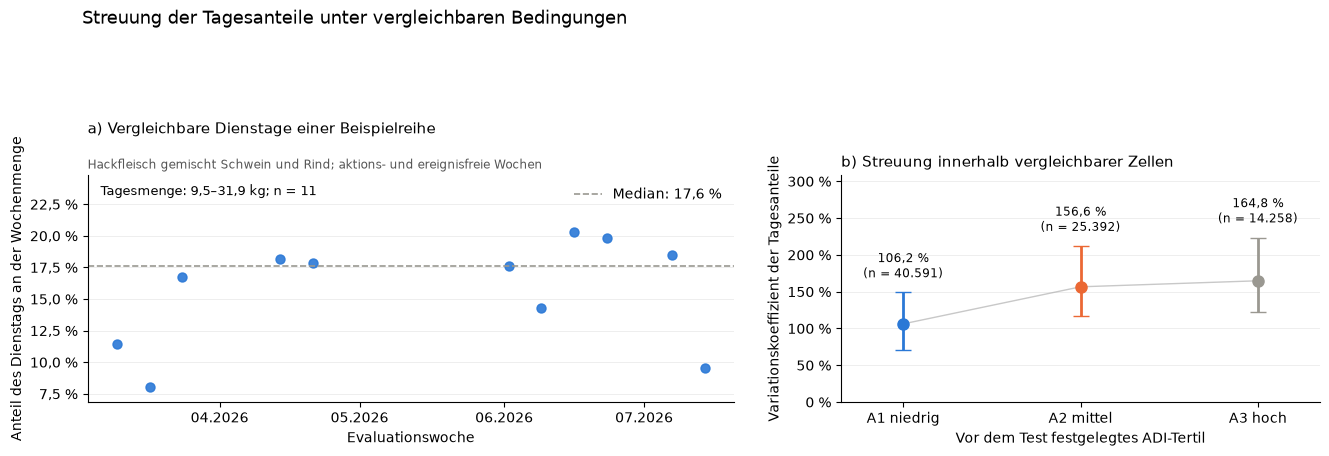

In [14]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from src.models.lightgbm.features.builder import _holiday_calendar

BLUE, ORANGE, GRAY = '#2a78d6', '#eb6834', '#9a9891'
ADI_LABELS = ['A1', 'A2', 'A3']
ADI_NAMES = ['A1 niedrig', 'A2 mittel', 'A3 hoch']
CLASSIFICATION_CUTOFF = pd.Timestamp('2026-02-02')

# Reconstruct the frozen ADI classes from history strictly before the cutoff.
con.execute('''
    CREATE OR REPLACE TEMP TABLE dispersion_rows AS
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
           CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
           actual::DOUBLE AS actual,
           EXTRACT(ISODOW FROM CAST(period AS DATE)) AS weekday,
           action_on_forecast_day::INTEGER AS act
    FROM read_csv_auto(?)
    WHERE is_active
''', [str(forecast_path)])

series_keys = con.execute('''
    SELECT DISTINCT ARTIKEL_ID, MARKT_ID FROM dispersion_rows
''').fetchdf()
con.register('dispersion_series_keys', series_keys)
frozen_history = con.execute('''
    WITH daily AS (
        SELECT d.ARTIKEL_ID::BIGINT AS ARTIKEL_ID,
               d.MARKT_ID::BIGINT AS MARKT_ID,
               CAST(d.DATE AS DATE) AS period,
               SUM(CAST(COALESCE(d.ABVERKAUFTE_MENGE_KG, 0) AS DOUBLE))
                   AS demand
        FROM read_parquet(?) AS d
        INNER JOIN dispersion_series_keys AS s
            ON d.ARTIKEL_ID = s.ARTIKEL_ID AND d.MARKT_ID = s.MARKT_ID
        WHERE d.is_active
          AND (d.is_fcm OR d.is_pseudo)
          AND d.WGR_ID IN (890, 900)
          AND CAST(d.DATE AS DATE) < ?
        GROUP BY d.ARTIKEL_ID, d.MARKT_ID, period
    )
    SELECT ARTIKEL_ID, MARKT_ID, COUNT(*) AS n_operational_days,
           COUNT_IF(demand > 0) AS n_pos,
           COUNT(*)::DOUBLE / NULLIF(COUNT_IF(demand > 0), 0) AS ADI
    FROM daily GROUP BY ARTIKEL_ID, MARKT_ID
''', [str(design.data_dir / '*.parquet'), CLASSIFICATION_CUTOFF.date()]).fetchdf()

series_regimes = series_keys.merge(
    frozen_history, on=['ARTIKEL_ID', 'MARKT_ID'], how='left',
    validate='one_to_one',
)
series_regimes[['n_operational_days', 'n_pos']] = series_regimes[[
    'n_operational_days', 'n_pos'
]].fillna(0).astype('int64')
eligible = series_regimes.n_pos.ge(5)
series_regimes['adi_bin'] = pd.Series(
    pd.NA, index=series_regimes.index, dtype='string'
)
series_regimes.loc[eligible, 'adi_bin'] = pd.qcut(
    series_regimes.loc[eligible, 'ADI'], 3, labels=ADI_LABELS
).astype('string').to_numpy()
assert eligible.sum() == 21_122
con.register(
    'frozen_adi_regimes',
    series_regimes.loc[eligible, ['ARTIKEL_ID', 'MARKT_ID', 'adi_bin']],
)

period_min, period_max = con.execute('''
    SELECT MIN(period), MAX(period) FROM dispersion_rows
''').fetchone()
event_calendar = _holiday_calendar(period_min, period_max)[
    ['period', 'holiday_event_window']
]
con.register('dispersion_calendar', event_calendar)
con.execute('''
    CREATE OR REPLACE TEMP TABLE adi_weekly_rows AS
    WITH joined AS (
        SELECT r.*, g.adi_bin, c.holiday_event_window
        FROM dispersion_rows AS r
        INNER JOIN frozen_adi_regimes AS g
            USING (ARTIKEL_ID, MARKT_ID)
        INNER JOIN dispersion_calendar AS c USING (period)
    )
    SELECT *,
           SUM(actual) OVER series_week AS week_total,
           MAX(act) OVER series_week AS week_has_action,
           MAX((holiday_event_window <> 'none')::INTEGER) OVER series_week
               AS week_has_event
    FROM joined
    WINDOW series_week AS (
        PARTITION BY ARTIKEL_ID, MARKT_ID, origin
    )
''')

cell_cv = con.execute('''
    WITH cells AS (
        SELECT adi_bin, ARTIKEL_ID, MARKT_ID, weekday,
               COUNT(*) AS observations,
               AVG(actual / week_total) AS mean_share,
               STDDEV_SAMP(actual / week_total) AS sd_share
        FROM adi_weekly_rows
        WHERE week_total > 0 AND week_has_action = 0 AND week_has_event = 0
        GROUP BY adi_bin, ARTIKEL_ID, MARKT_ID, weekday
        HAVING COUNT(*) >= 5 AND AVG(actual / week_total) > 0
    )
    SELECT *, sd_share / mean_share AS cv FROM cells
''').fetchdf()
cell_cv['adi_bin'] = pd.Categorical(
    cell_cv.adi_bin, categories=ADI_LABELS, ordered=True
)
dispersion_summary = (
    cell_cv.groupby('adi_bin', observed=True).cv
    .agg(cells='size', q25=lambda values: values.quantile(.25),
         median='median', q75=lambda values: values.quantile(.75))
    .reindex(ADI_LABELS).reset_index()
)
display(dispersion_summary.style.format({
    'cells': '{:,.0f}', 'q25': '{:.1%}', 'median': '{:.1%}', 'q75': '{:.1%}',
}))

# Select a high-volume, almost continuously selling A1 example with enough
# comparable Tuesdays; the rule is deterministic rather than hand-picked.
EXAMPLE_ARTICLE, EXAMPLE_STORE = con.execute('''
    SELECT ARTIKEL_ID, MARKT_ID
    FROM adi_weekly_rows
    WHERE adi_bin = 'A1'
    GROUP BY ARTIKEL_ID, MARKT_ID
    HAVING AVG((actual > 0)::INTEGER) >= 0.99
       AND COUNT_IF(weekday = 2 AND week_has_action = 0
                    AND week_has_event = 0) >= 5
    ORDER BY SUM(actual) DESC
    LIMIT 1
''').fetchone()
EXAMPLE_ARTICLE_BEZ, = con.execute('''
    SELECT ARG_MAX(ARTIKEL_BEZ, CAST(DATE AS DATE)) FILTER (
        WHERE ARTIKEL_BEZ IS NOT NULL AND TRIM(ARTIKEL_BEZ) <> ''
    )
    FROM read_parquet(?)
    WHERE ARTIKEL_ID = ? AND MARKT_ID = ?
''', [str(design.data_dir / '*.parquet'),
      EXAMPLE_ARTICLE, EXAMPLE_STORE]).fetchone()
if not EXAMPLE_ARTICLE_BEZ:
    raise ValueError('Missing ARTIKEL_BEZ for the selected example series')
example = con.execute('''
    SELECT period, actual, actual / week_total AS day_share
    FROM adi_weekly_rows
    WHERE ARTIKEL_ID = ? AND MARKT_ID = ? AND weekday = 2
      AND week_total > 0 AND week_has_action = 0 AND week_has_event = 0
    ORDER BY period
''', [EXAMPLE_ARTICLE, EXAMPLE_STORE]).fetchdf()
example['period'] = pd.to_datetime(example.period)

def percent_de(value, decimals=1):
    return f'{100 * value:.{decimals}f} %'.replace('.', ',')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.4, 5.1),
                               gridspec_kw={'width_ratios': [1.35, 1]})

ax1.scatter(example.period, example.day_share, s=42, color=BLUE, alpha=.9)
median_share = example.day_share.median()
ax1.axhline(median_share, color=GRAY, linewidth=1.2, linestyle='--',
            label=f'Median: {percent_de(median_share)}')
ax1.set_title('a) Vergleichbare Dienstage einer Beispielreihe',
              fontsize=11, loc='left', pad=30)
ax1.text(0, 1.015,
         f'{EXAMPLE_ARTICLE_BEZ}; aktions- und ereignisfreie Wochen',
         transform=ax1.transAxes, fontsize=8.5, color='#555555', va='bottom')
ax1.set_xlabel('Evaluationswoche')
ax1.set_ylabel('Anteil des Dienstags an der Wochenmenge')
ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: percent_de(value))
)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))
ax1.set_ylim(example.day_share.min() * .85, example.day_share.max() * 1.22)
ax1.legend(frameon=False, loc='upper right')
ax1.text(.02, .96,
         ('Tagesmenge: '
          f'{example.actual.min():.1f}–{example.actual.max():.1f} kg; '
          f'n = {len(example)}').replace('.', ','),
         transform=ax1.transAxes, va='top', fontsize=9)

positions = np.arange(1, 4)
medians = dispersion_summary['median'].to_numpy()
lower = medians - dispersion_summary['q25'].to_numpy()
upper = dispersion_summary['q75'].to_numpy() - medians
colors = [BLUE, ORANGE, GRAY]
for x, median, lo, hi, color, cells in zip(
    positions, medians, lower, upper, colors, dispersion_summary['cells']
):
    ax2.errorbar(x, median, yerr=[[lo], [hi]], fmt='o', markersize=8,
                 capsize=6, linewidth=2, color=color)
    cell_count = f'{int(cells):,}'.replace(',', '.')
    ax2.annotate(f'{percent_de(median)}\n(n = {cell_count})',
                 xy=(x, median + hi), xytext=(0, 8),
                 textcoords='offset points', ha='center', va='bottom',
                 fontsize=8.5)
ax2.plot(positions, medians, color='#c8c8c8', linewidth=1, zorder=0)
ax2.set_xticks(positions, ADI_NAMES)
ax2.set_title('b) Streuung innerhalb vergleichbarer Zellen', fontsize=11, loc='left')
ax2.set_xlabel('Vor dem Test festgelegtes ADI-Tertil')
ax2.set_ylabel('Variationskoeffizient der Tagesanteile')
ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: percent_de(value, decimals=0))
)
ax2.set_xlim(.65, 3.35)
ax2.set_ylim(0, max(dispersion_summary.q75) * 1.38)

for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
fig.suptitle('Streuung der Tagesanteile unter vergleichbaren Bedingungen',
             fontsize=13, x=.065, y=.985, ha='left')
fig.tight_layout(rect=[0, .10, 1, .86], w_pad=2.4)
plt.show()

### Addendum 3 conclusions

The high band's 37.8% decomposes into three parts with very different
tractability:

1. **~10 pp: weekly totals** (37.8% → 27.8% with true week totals under the
   model's own shape). Systematic — the weekly signed bias swings ±20% in
   event/post-event weeks — and therefore the legitimate target of the
   event-feature program.
2. **≤1–2 pp: within-week allocation.** The model's shape already beats the
   future-knowledge static weekday profile; the best observable-conditioned
   profile (weekday × action) adds ~1 pp, and granting **perfect same-day
   footfall** on top reaches 25.9% — an upper bound of ~1.8 pp over the model's
   shape that no real forecast attains, since target-day footfall is itself
   unknown 1–7 days ahead and its predictable part (weekday, actions, holidays)
   is already in the model's features. Log-footfall deviations explain only
   r ≈ 0.20–0.24 of day-level demand deviations (~4–6% of variance).
   **Footfall data is therefore not a lever at this grain**; at most it is a
   cheap auxiliary regressor for week-level store traffic trends.
3. **~24 pp: irreducible day-level dispersion.** Same store, same article, same
   weekday, same promo state, week level removed — daily demand still scatters
   with a ~50% median coefficient of variation. Oracle B's 3.0% is reachable
   only by copying the realized draw; no leakage-free forecast of any kind
   closes this part.